In [2]:
import numpy as np, matplotlib.pyplot as plt, utils, pandas as pd

train =  pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
names = utils.load_items()
M = utils.build_user_item(train)
print('Matrix:', M.shape)

Matrix: (138, 130)


In [4]:
pop = utils.PopularityBaseline().fit(M)
cf = utils.ItemBasedCF().fit(M)
svd = utils.SVDRecommender().fit(M, n_components=15)
print('Datasets are fitted.')

Datasets are fitted.


In [5]:
rmse = {n:round(utils.rmse_on_test(m, test),4) for n,m in [('Popularity', pop), ('Item-CF', cf), ('SVD', svd)]}
rmse_df = pd.Series(rmse, name='RMSE').to_frame()
rmse_df

,RMSE
Popularity,0.7916
Item-CF,0.7012
SVD,0.5993


In [7]:
#Alternative way

rmse = {}

rmse['Popularity'] = round(utils.rmse_on_test(pop, test), 4)
rmse['Item-CF'] = round(utils.rmse_on_test(cf, test), 4)
rmse['SVD'] = round(utils.rmse_on_test(svd, test), 4)

In [9]:
rmse_df = pd.Series(rmse, name='RMSE').to_frame()

In [10]:
rmse_df

,RMSE
Popularity,0.7916
Item-CF,0.7012
SVD,0.5993


In [13]:
rows = []

for n,m in [('Popularity', pop), ('Item-CF', cf), ('SVD', svd)]:
    r = utils.precision_recall_at_k(m,M,test,k=10,rel_threshold=2.0)
    rows.append({'model':n, 'precision@k':r['precision@k'], 'recall@k':r['recall@k'], 'n_users':r['n_users_evaluated']})
rank_df = pd.DataFrame(rows)
rank_df

,model,precision@k,recall@k,n_users
0,Popularity,0.0100,0.0778,60
1,Item-CF,0.0233,0.1764,60
2,SVD,0.0317,0.2361,60


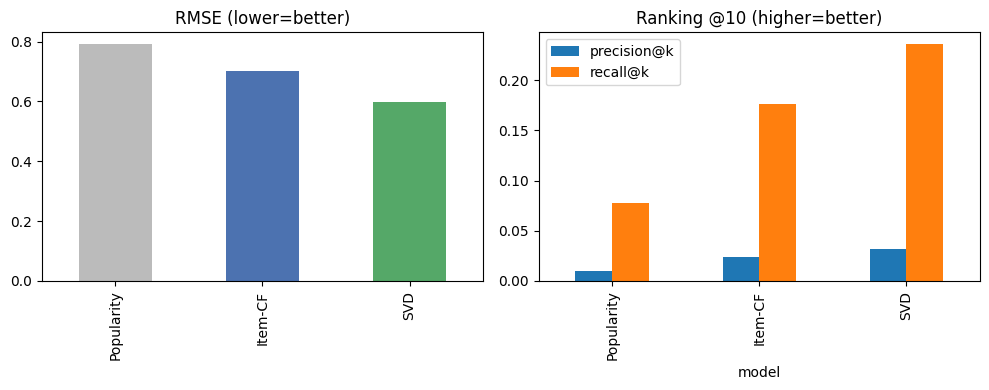

In [16]:
fig,ax = plt.subplots(1,2,figsize=(10,4))
rmse_df['RMSE'].plot(kind='bar', ax=ax[0],color=['#bbb','#4c72b0','#55a868'])
ax[0].set_title('RMSE (lower=better)')

rank_df.set_index('model')[['precision@k', 'recall@k']].plot(kind='bar', ax=ax[1])
ax[1].set_title('Ranking @10 (higher=better)')

plt.tight_layout()
plt.show()

In [19]:
uid = M.index[0]
print('Recommendations for consumer', uid, '\n')
utils.recommend(svd, M, uid, items_lookup=names, n=10)

Recommendations for consumer U1001 



,item,title,score
0,132921,crudalia,1.403
1,135081,El Club,1.390
2,132862,La Posada del Virrey,1.313
3,132834,Gorditas Doa Gloria,1.312
4,135047,Restaurante Casa de las Flores,1.312
5,132572,Cafe Chaires,1.293
6,135026,la Cantina,1.290
7,135032,Cafeteria y Restaurant El Pacifico,1.274
8,135040,Restaurant los Compadres,1.271
9,135076,Restaurante Pueblo Bonito,1.236
